# DBSCAN on Synthetic Datasets

**Density-Based Spatial Clustering of Applications with Noise (DBSCAN)** is an unsupervised clustering algorithm that groups together points that are closely packed in space and marks points that lie in low-density regions as **outliers (noise)**.

---

### How DBSCAN Works

DBSCAN uses two key hyperparameters:

| Parameter | Description |
|-----------|-------------|
| **ε (eps)** | The maximum distance between two points for them to be considered neighbors |
| **min_samples** | Minimum number of points required to form a dense region (core point) |

**Point Classifications:**
- 🟢 **Core Point** — Has at least `min_samples` neighbors within distance `ε`
- 🔵 **Border Point** — Within `ε` of a core point but has fewer than `min_samples` neighbors
- 🔴 **Noise Point** — Not a core or border point (labeled as `-1`)

---

### Why DBSCAN on Synthetic Datasets?

Unlike K-Means, DBSCAN can discover clusters of **arbitrary shape**. This notebook demonstrates DBSCAN on two sklearn synthetic datasets that challenge traditional centroid-based methods:

1. **Make Moons** — Two interleaving half-circles
2. **Make Circles** — Concentric circles with varying density

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#333',
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
})

RANDOM_STATE = 42
print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


## 2. DBSCAN Implementation from Scratch

Before using sklearn's implementation, we'll build our own DBSCAN to understand the core logic.

In [2]:
class MyDBSCAN:
    """
    Custom DBSCAN implementation from scratch (BallTree-accelerated).
    
    Parameters
    ----------
    eps : float
        Maximum distance for neighborhood queries.
    min_samples : int
        Minimum neighbors to qualify as a core point.
    """

    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def fit_predict(self, X):
        """
        Fit and return cluster labels.
        -1 indicates noise.
        """
        from sklearn.neighbors import BallTree
        n = len(X)
        labels = np.full(n, -1, dtype=int)   # -1 = unvisited / noise
        cluster_id = 0

        # Pre-compute all neighbors using BallTree for efficiency
        tree = BallTree(X)
        all_neighbors = tree.query_radius(X, r=self.eps)

        def get_neighbors(idx):
            return all_neighbors[idx]

        for i in range(n):
            if labels[i] != -1:
                continue  # already assigned

            neighbors = get_neighbors(i)

            if len(neighbors) < self.min_samples:
                continue  # stays noise

            # i is a core point — start a new cluster
            labels[i] = cluster_id
            seed_set = set(neighbors.tolist())
            seed_set.discard(i)

            while seed_set:
                current = seed_set.pop()

                if labels[current] == -1:
                    labels[current] = cluster_id

                if labels[current] >= 0 and labels[current] != cluster_id:
                    continue

                labels[current] = cluster_id
                current_neighbors = get_neighbors(current)

                if len(current_neighbors) >= self.min_samples:
                    for nb in current_neighbors:
                        if labels[nb] == -1:
                            seed_set.add(nb)

            cluster_id += 1

        return labels


print("MyDBSCAN class defined ✓")

MyDBSCAN class defined ✓


## 3. Helper Functions

In [3]:
# Vibrant cluster color palette
CLUSTER_COLORS = [
    '#00d4ff', '#ff6b6b', '#51cf66', '#ffd43b',
    '#cc5de8', '#ff922b', '#74c0fc', '#f783ac',
]
NOISE_COLOR = '#555555'


def get_color_map(labels):
    """Build a color array: noise → gray, clusters → palette."""
    unique_clusters = sorted(set(labels) - {-1})
    color_map = {c: CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
                 for i, c in enumerate(unique_clusters)}
    color_map[-1] = NOISE_COLOR
    return [color_map[l] for l in labels]


def plot_clusters(ax, X, labels, title, eps=None, min_samples=None):
    """Scatter plot of DBSCAN results with annotations."""
    colors = get_color_map(labels)
    n_clusters = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=colors, s=18, alpha=0.8, linewidths=0)

    subtitle = f"Clusters: {n_clusters}  |  Noise: {n_noise}"
    if eps and min_samples:
        subtitle += f"  |  ε={eps}, min_samples={min_samples}"
    ax.set_title(f"{title}\n{subtitle}", fontsize=10, pad=8, color='#e0e0e0')
    ax.grid(True, linestyle='--')
    ax.set_aspect('equal')

    # Legend patches
    patches = []
    for cid in sorted(set(labels) - {-1}):
        patches.append(mpatches.Patch(
            color=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
            label=f'Cluster {cid}'
        ))
    if n_noise > 0:
        patches.append(mpatches.Patch(color=NOISE_COLOR, label='Noise'))
    ax.legend(handles=patches, fontsize=7, loc='upper right',
              facecolor='#111', edgecolor='#444', labelcolor='white')


def silhouette(X, labels):
    """Return silhouette score, or None if < 2 clusters."""
    unique = set(labels) - {-1}
    if len(unique) < 2:
        return None
    mask = labels != -1
    return silhouette_score(X[mask], labels[mask])


print("Helper functions defined ✓")

Helper functions defined ✓


---
## Dataset 1: Make Moons 🌙

`make_moons` generates two interleaving half-circles. This is a classic benchmark showing that algorithms like K-Means (which assumes convex clusters) fail, while DBSCAN succeeds.

**Noise levels tested:** low, medium, high

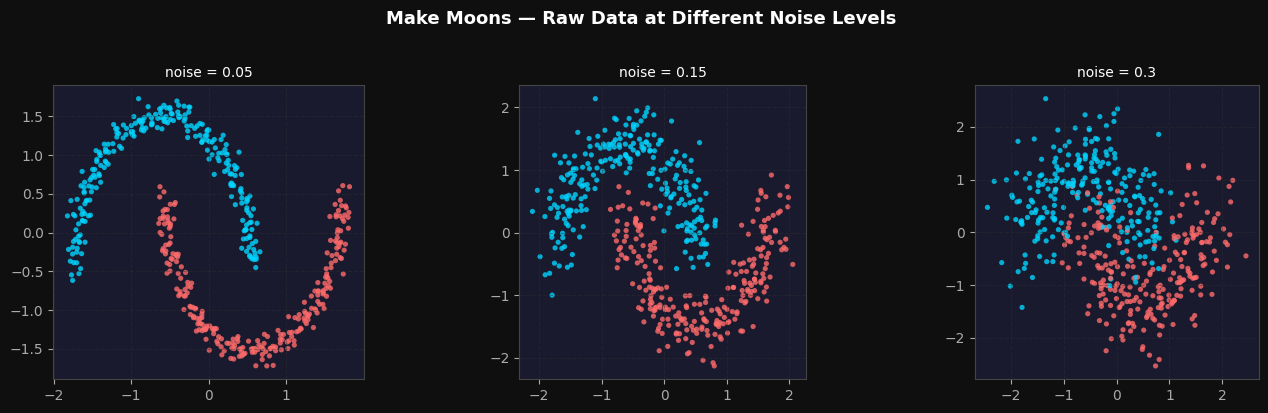

Moons datasets generated ✓


In [4]:
# ── Generate Make Moons at three noise levels ──────────────────────────────
noise_levels = [0.05, 0.15, 0.30]
n_samples     = 500

moons_datasets = {}
for noise in noise_levels:
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=RANDOM_STATE)
    X = StandardScaler().fit_transform(X)
    moons_datasets[noise] = (X, y)

# ── Plot raw data ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Make Moons — Raw Data at Different Noise Levels',
             fontsize=13, fontweight='bold', color='white', y=1.02)

moon_colors = ['#00d4ff', '#ff6b6b']

for ax, noise in zip(axes, noise_levels):
    X, y = moons_datasets[noise]
    c = [moon_colors[label] for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=c, s=14, alpha=0.8, linewidths=0)
    ax.set_title(f'noise = {noise}', fontsize=10, color='white')
    ax.grid(True, linestyle='--')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('moons_raw.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Moons datasets generated ✓")

### 3a. K-Distance Plot — Choosing ε for Make Moons

The **k-distance plot** (also called the elbow plot) helps select ε. We sort points by their distance to the k-th nearest neighbor. The "elbow" in the curve indicates a good ε value — below it, points are dense; above it, they are sparse (noise).

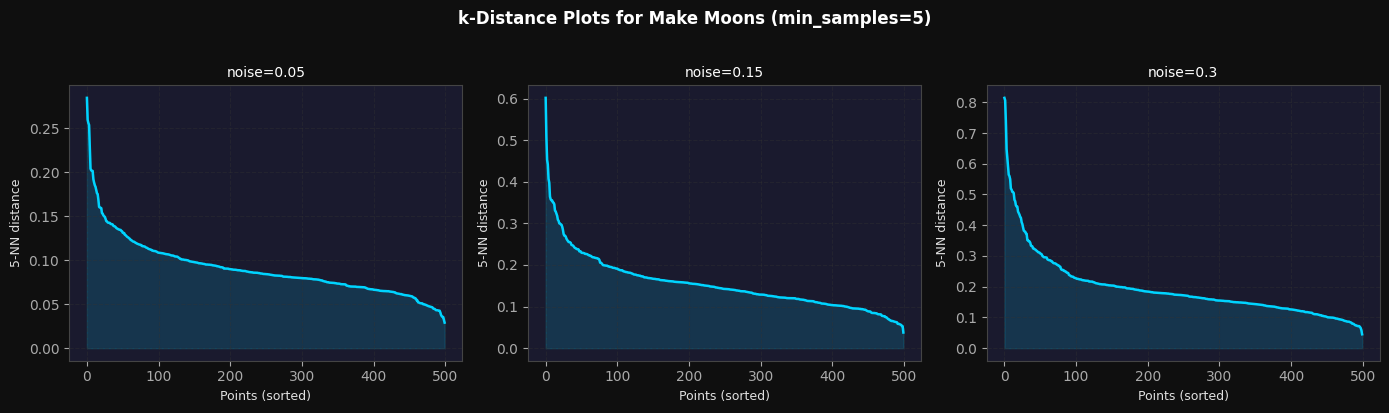

k-distance plots generated ✓


In [5]:
def plot_k_distance(X, min_samples=5, ax=None, title='k-Distance Plot'):
    """Plot sorted k-th nearest-neighbor distances."""
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, -1])[::-1]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(k_distances, color='#00d4ff', linewidth=1.8)
    ax.fill_between(range(len(k_distances)), k_distances, alpha=0.15, color='#00d4ff')
    ax.set_xlabel('Points (sorted)', fontsize=9)
    ax.set_ylabel(f'{min_samples}-NN distance', fontsize=9)
    ax.set_title(title, fontsize=10, color='white')
    ax.grid(True, linestyle='--')

    if standalone:
        plt.tight_layout()
        plt.savefig('k_distance.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
        plt.show()


# Show k-distance for the medium-noise moons (noise=0.15)
X_moon_med, _ = moons_datasets[0.15]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('k-Distance Plots for Make Moons (min_samples=5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

for ax, noise in zip(axes, noise_levels):
    X_n, _ = moons_datasets[noise]
    plot_k_distance(X_n, min_samples=5, ax=ax, title=f'noise={noise}')

plt.tight_layout()
plt.savefig('moons_kdist.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("k-distance plots generated ✓")

### 3b. Apply DBSCAN to Make Moons

We compare our **custom DBSCAN** against **sklearn's DBSCAN** side-by-side, and show how varying ε changes clustering behavior.

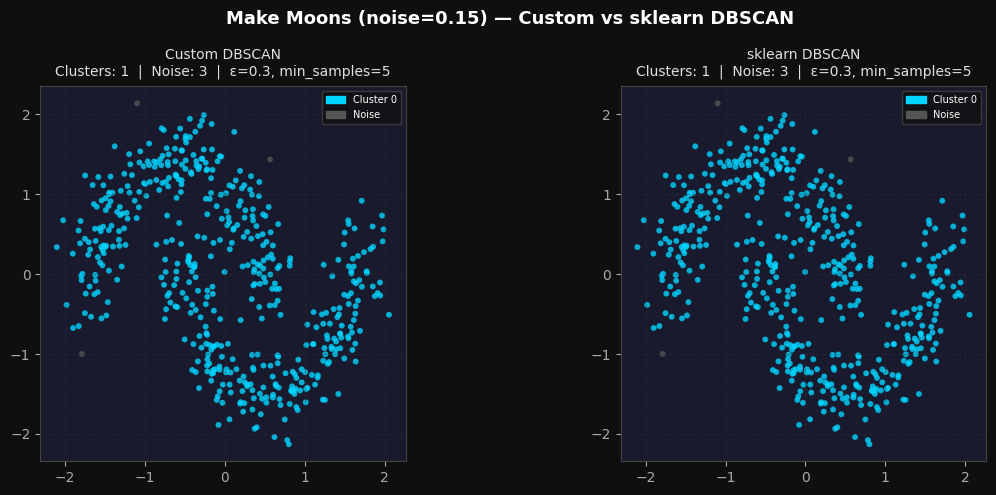

Custom  DBSCAN — Silhouette: N/A
sklearn DBSCAN — Silhouette: N/A


In [6]:
# ── Side-by-side: Custom vs sklearn DBSCAN on medium noise ─────────────────
X_moon, _ = moons_datasets[0.15]
EPS_MOON, MIN_S_MOON = 0.3, 5

labels_custom = MyDBSCAN(eps=EPS_MOON, min_samples=MIN_S_MOON).fit_predict(X_moon)
labels_sklearn = DBSCAN(eps=EPS_MOON, min_samples=MIN_S_MOON).fit_predict(X_moon)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Make Moons (noise=0.15) — Custom vs sklearn DBSCAN',
             fontsize=13, fontweight='bold', color='white')

plot_clusters(ax1, X_moon, labels_custom,
              'Custom DBSCAN', eps=EPS_MOON, min_samples=MIN_S_MOON)
plot_clusters(ax2, X_moon, labels_sklearn,
              'sklearn DBSCAN', eps=EPS_MOON, min_samples=MIN_S_MOON)

plt.tight_layout()
plt.savefig('moons_custom_vs_sklearn.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Silhouette scores
sc_custom  = silhouette(X_moon, labels_custom)
sc_sklearn = silhouette(X_moon, labels_sklearn)
print(f"Custom  DBSCAN — Silhouette: {f"{f"{sc_custom:.4f}" if sc_custom is not None else "N/A"}" if sc_custom is not None else "N/A"}")
print(f"sklearn DBSCAN — Silhouette: {f"{f"{sc_sklearn:.4f}" if sc_sklearn is not None else "N/A"}" if sc_sklearn is not None else "N/A"}")

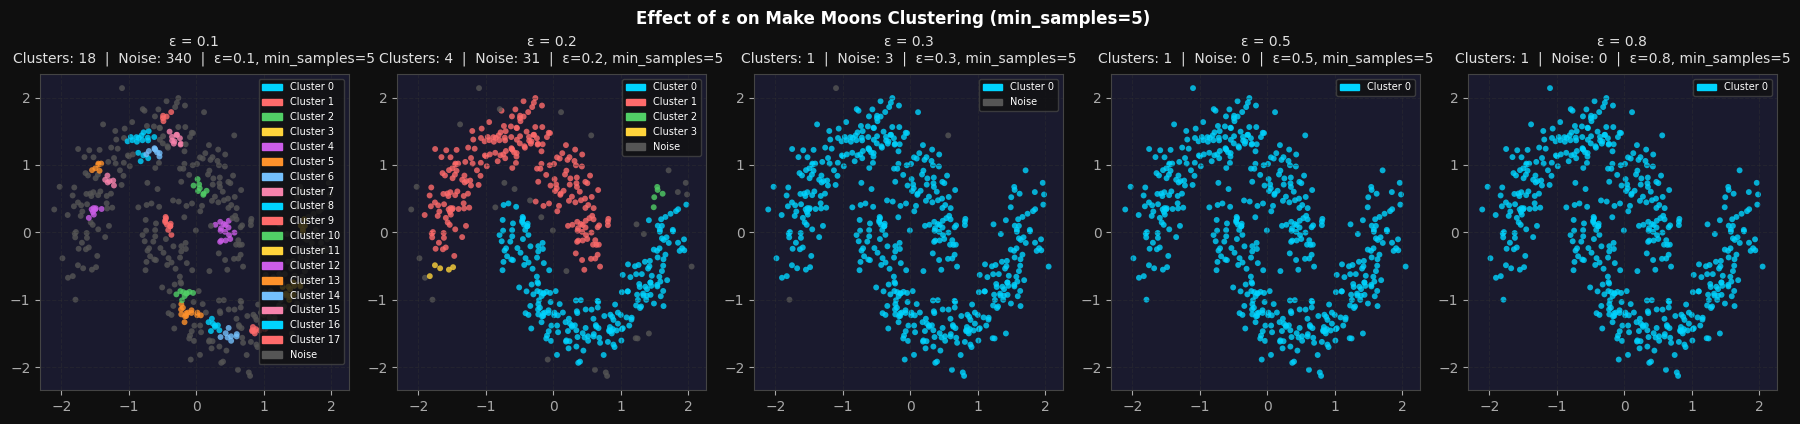

ε sweep complete ✓


In [7]:
# ── Effect of ε on Make Moons (noise=0.15) ─────────────────────────────────
eps_values   = [0.10, 0.20, 0.30, 0.50, 0.80]
min_samples  = 5

fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 4))
fig.suptitle('Effect of ε on Make Moons Clustering (min_samples=5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_moon)
    plot_clusters(ax, X_moon, labels, f'ε = {eps}', eps=eps, min_samples=min_samples)

plt.tight_layout()
plt.savefig('moons_eps_sweep.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("ε sweep complete ✓")

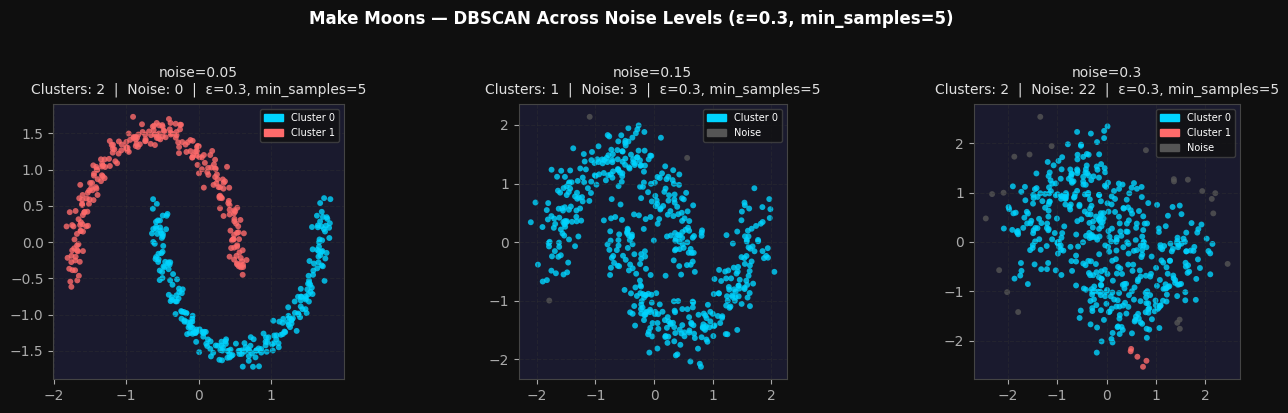

   Noise | Clusters | Noise pts | Silhouette
----------------------------------------------
    0.05 |        2 |         0 |     0.3893
    0.15 |        1 |         3 |        N/A
    0.30 |        2 |        22 |     0.2548


In [8]:
# ── Effect of noise level on Make Moons with fixed good params ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Make Moons — DBSCAN Across Noise Levels (ε=0.3, min_samples=5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

results = []
for ax, noise in zip(axes, noise_levels):
    X_n, _ = moons_datasets[noise]
    labels = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_n)
    sc = silhouette(X_n, labels)
    plot_clusters(ax, X_n, labels, f'noise={noise}', eps=0.3, min_samples=5)
    results.append({'noise': noise, 'n_clusters': len(set(labels)-{-1}),
                    'n_noise': list(labels).count(-1), 'silhouette': sc})

plt.tight_layout()
plt.savefig('moons_noise_sweep.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"{'Noise':>8} | {'Clusters':>8} | {'Noise pts':>9} | {'Silhouette':>10}")
print('-' * 46)
for r in results:
    sc_str = f"{r['silhouette']:.4f}" if r['silhouette'] else 'N/A'
    print(f"{r['noise']:>8.2f} | {r['n_clusters']:>8} | {r['n_noise']:>9} | {sc_str:>10}")

---
## Dataset 2: Make Circles ⭕

`make_circles` generates two concentric circles. The inner circle has a smaller radius and different density — DBSCAN excels at separating these where K-Means (which uses Euclidean distance to centroids) completely fails.

**Factor tested:** noise level and the `factor` parameter (size ratio between circles)

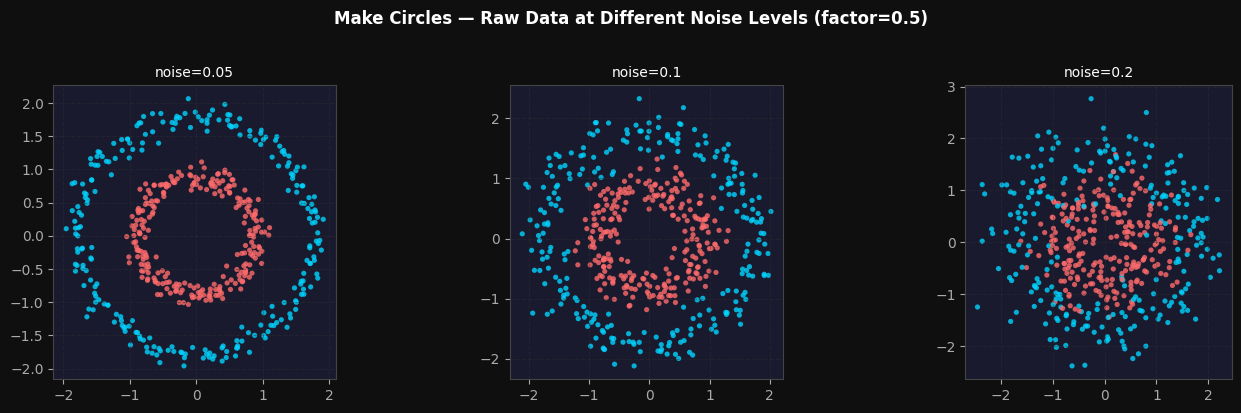

Circles datasets generated ✓


In [9]:
# ── Generate Make Circles ──────────────────────────────────────────────────
noise_levels_c = [0.05, 0.10, 0.20]
factors        = [0.3, 0.5, 0.7]

circles_by_noise = {}
for noise in noise_levels_c:
    X, y = make_circles(n_samples=500, noise=noise, factor=0.5, random_state=RANDOM_STATE)
    X = StandardScaler().fit_transform(X)
    circles_by_noise[noise] = (X, y)

circles_by_factor = {}
for factor in factors:
    X, y = make_circles(n_samples=500, noise=0.05, factor=factor, random_state=RANDOM_STATE)
    X = StandardScaler().fit_transform(X)
    circles_by_factor[factor] = (X, y)

# ── Plot raw data by noise ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Make Circles — Raw Data at Different Noise Levels (factor=0.5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

circ_colors = ['#00d4ff', '#ff6b6b']
for ax, noise in zip(axes, noise_levels_c):
    X, y = circles_by_noise[noise]
    c = [circ_colors[l] for l in y]
    ax.scatter(X[:, 0], X[:, 1], c=c, s=14, alpha=0.8, linewidths=0)
    ax.set_title(f'noise={noise}', fontsize=10, color='white')
    ax.grid(True, linestyle='--')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('circles_raw.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Circles datasets generated ✓")

### 4a. K-Distance Plot — Choosing ε for Make Circles

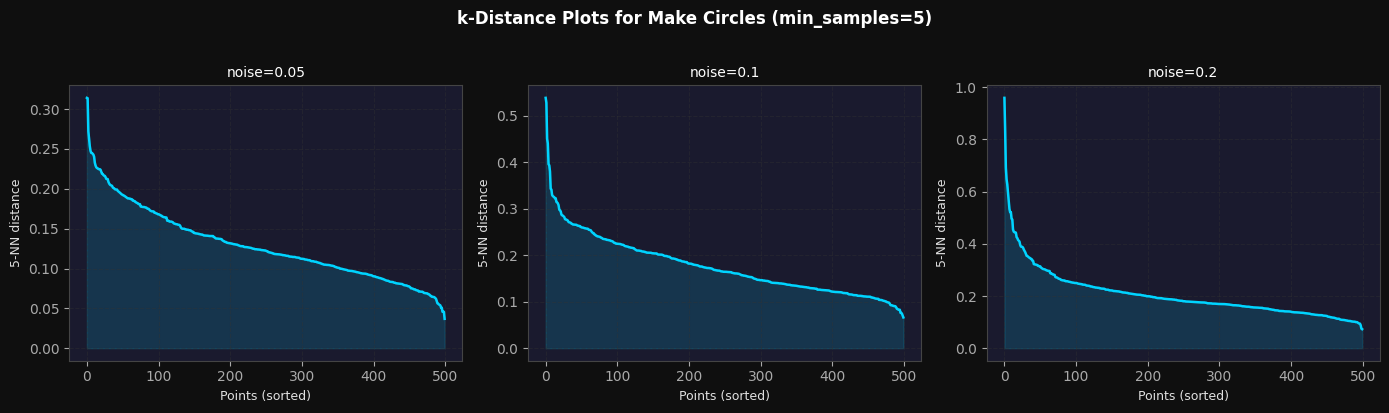

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('k-Distance Plots for Make Circles (min_samples=5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

for ax, noise in zip(axes, noise_levels_c):
    X_n, _ = circles_by_noise[noise]
    plot_k_distance(X_n, min_samples=5, ax=ax, title=f'noise={noise}')

plt.tight_layout()
plt.savefig('circles_kdist.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

### 4b. Apply DBSCAN to Make Circles

We compare K-Means (which fails) against DBSCAN (which succeeds), then study the effect of ε and the `factor` parameter.

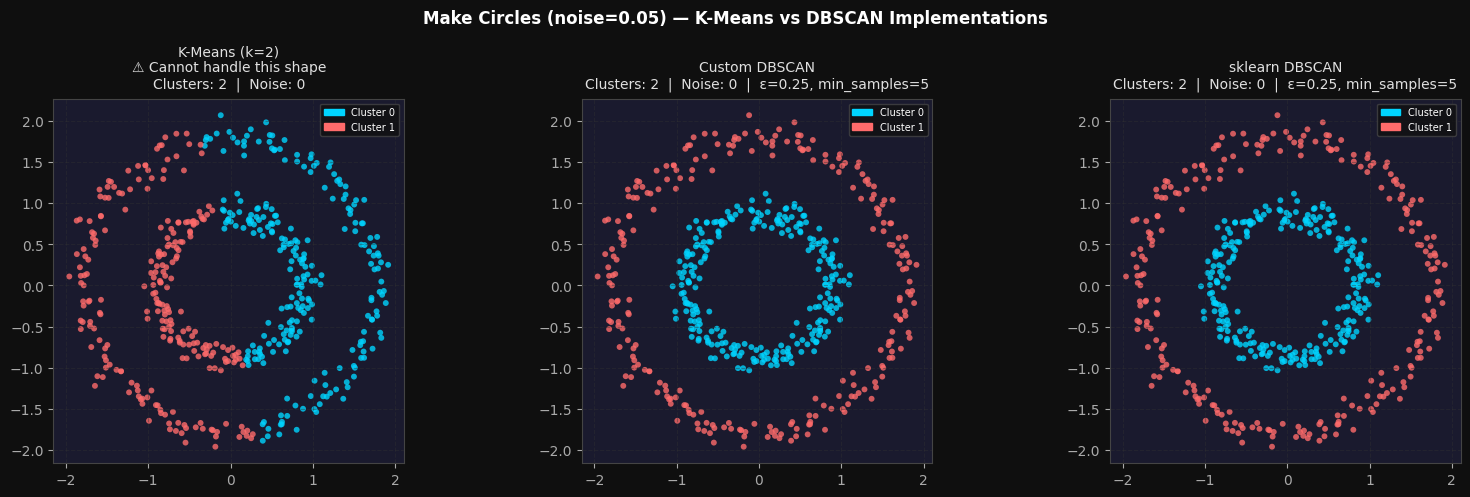

K-Means  — Silhouette: 0.3531
Custom   — Silhouette: 0.1126
sklearn  — Silhouette: 0.1126


In [11]:
from sklearn.cluster import KMeans

# ── K-Means vs DBSCAN on circles (noise=0.05) ─────────────────────────────
X_circ, y_circ = circles_by_noise[0.05]
EPS_CIRC, MIN_S_CIRC = 0.25, 5

labels_km     = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_circ)
labels_db     = DBSCAN(eps=EPS_CIRC, min_samples=MIN_S_CIRC).fit_predict(X_circ)
labels_custom = MyDBSCAN(eps=EPS_CIRC, min_samples=MIN_S_CIRC).fit_predict(X_circ)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Make Circles (noise=0.05) — K-Means vs DBSCAN Implementations',
             fontsize=12, fontweight='bold', color='white')

# K-Means (note: uses cluster IDs 0 and 1, no -1, so reuse the same helper)
plot_clusters(axes[0], X_circ, labels_km, 'K-Means (k=2)\n⚠️ Cannot handle this shape')
plot_clusters(axes[1], X_circ, labels_custom, 'Custom DBSCAN', eps=EPS_CIRC, min_samples=MIN_S_CIRC)
plot_clusters(axes[2], X_circ, labels_db,     'sklearn DBSCAN', eps=EPS_CIRC, min_samples=MIN_S_CIRC)

plt.tight_layout()
plt.savefig('circles_kmeans_vs_dbscan.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

sc_km = silhouette(X_circ, labels_km)
sc_db = silhouette(X_circ, labels_db)
sc_cu = silhouette(X_circ, labels_custom)
print(f"K-Means  — Silhouette: {f"{f"{sc_km:.4f}" if sc_km is not None else "N/A"}" if sc_km is not None else "N/A"}")
print(f"Custom   — Silhouette: {f"{f"{sc_cu:.4f}" if sc_cu is not None else "N/A"}" if sc_cu is not None else "N/A"}")
print(f"sklearn  — Silhouette: {f"{f"{sc_db:.4f}" if sc_db is not None else "N/A"}" if sc_db is not None else "N/A"}")

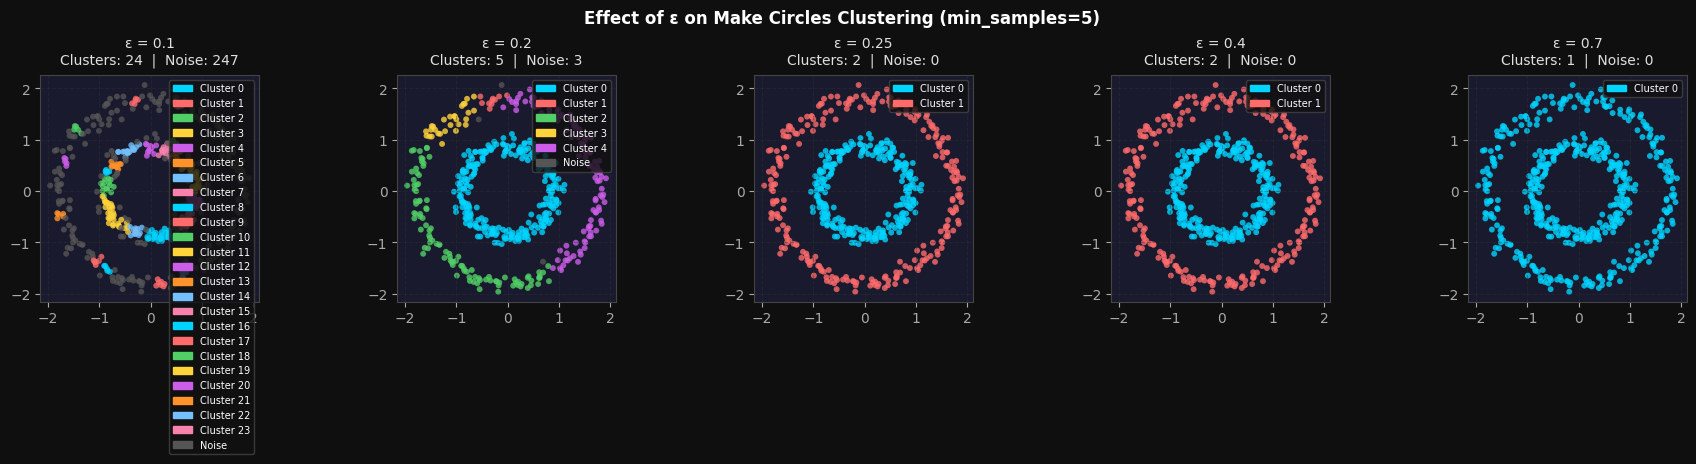

In [12]:
# ── Effect of ε on Make Circles (noise=0.05) ────────────────────────────────
eps_values_c = [0.10, 0.20, 0.25, 0.40, 0.70]

fig, axes = plt.subplots(1, len(eps_values_c), figsize=(18, 4))
fig.suptitle('Effect of ε on Make Circles Clustering (min_samples=5)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

for ax, eps in zip(axes, eps_values_c):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_circ)
    plot_clusters(ax, X_circ, labels, f'ε = {eps}')

plt.tight_layout()
plt.savefig('circles_eps_sweep.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

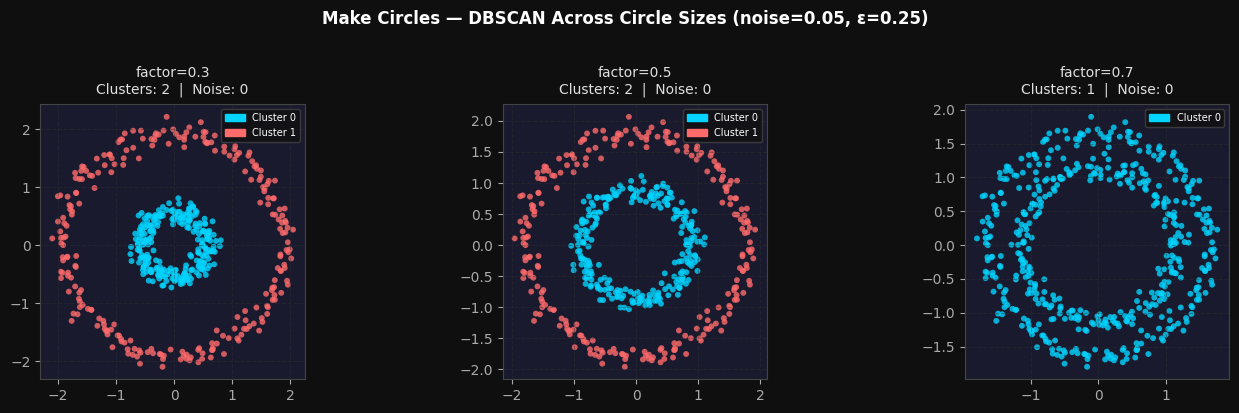

  Factor | Clusters | Noise pts | Silhouette
----------------------------------------------
     0.3 |        2 |         0 |     0.2074
     0.5 |        2 |         0 |     0.1126
     0.7 |        1 |         0 |        N/A


In [13]:
# ── Effect of circle factor (inner/outer ratio) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Make Circles — DBSCAN Across Circle Sizes (noise=0.05, ε=0.25)',
             fontsize=12, fontweight='bold', color='white', y=1.02)

factor_results = []
for ax, factor in zip(axes, factors):
    X_f, _ = circles_by_factor[factor]
    labels  = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_f)
    sc = silhouette(X_f, labels)
    plot_clusters(ax, X_f, labels, f'factor={factor}')
    factor_results.append({'factor': factor,
                           'n_clusters': len(set(labels)-{-1}),
                           'n_noise': list(labels).count(-1),
                           'silhouette': sc})

plt.tight_layout()
plt.savefig('circles_factor_sweep.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"{'Factor':>8} | {'Clusters':>8} | {'Noise pts':>9} | {'Silhouette':>10}")
print('-' * 46)
for r in factor_results:
    sc_str = f"{r['silhouette']:.4f}" if r['silhouette'] else 'N/A'
    print(f"{r['factor']:>8.1f} | {r['n_clusters']:>8} | {r['n_noise']:>9} | {sc_str:>10}")

---
## 5. Hyperparameter Grid Search

We sweep over ε and min_samples for both datasets and visualize the silhouette score heatmap to identify the best parameter regions.

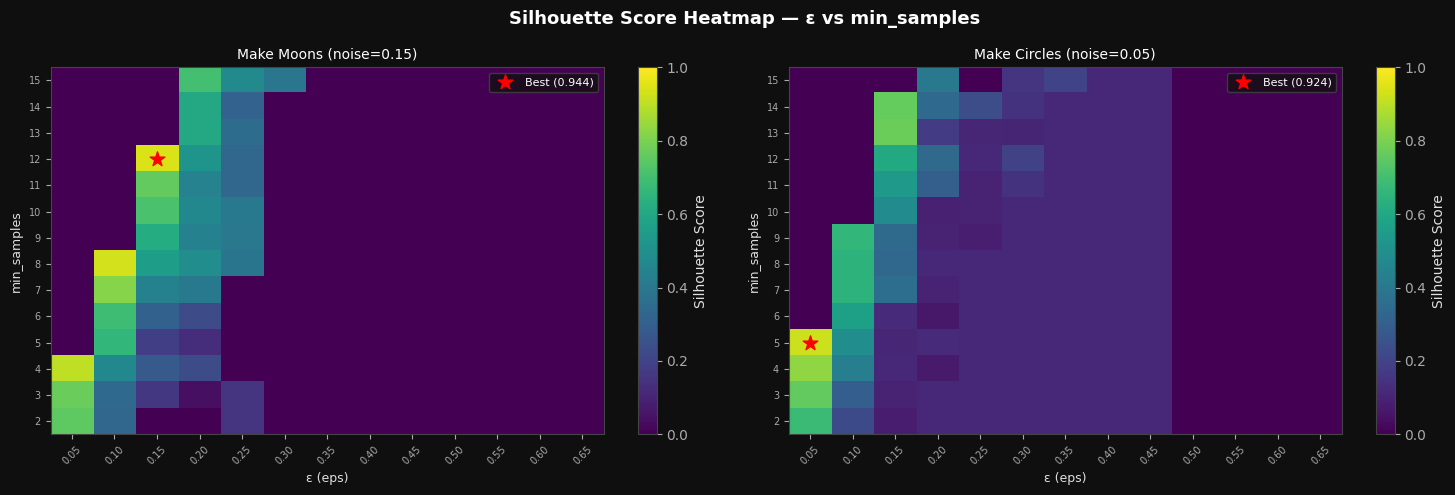

Best Moons: ε=0.15, min_samples=12, silhouette=0.9438
Best Circles: ε=0.05, min_samples=5, silhouette=0.9243


In [14]:
def param_grid_search(X, eps_range, min_samples_range):
    """Return a 2D array of silhouette scores for all (eps, min_samples) combos."""
    grid = np.zeros((len(min_samples_range), len(eps_range)))

    for i, ms in enumerate(min_samples_range):
        for j, eps in enumerate(eps_range):
            labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            sc = silhouette(X, labels)
            grid[i, j] = sc if sc is not None else 0.0

    return grid


eps_range = np.arange(0.05, 0.70, 0.05)
ms_range  = list(range(2, 16))

# Grid for moons (noise=0.15)
X_m, _ = moons_datasets[0.15]
grid_moons = param_grid_search(X_m, eps_range, ms_range)

# Grid for circles (noise=0.05)
X_c, _ = circles_by_noise[0.05]
grid_circles = param_grid_search(X_c, eps_range, ms_range)

# Plot heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Silhouette Score Heatmap — ε vs min_samples',
             fontsize=13, fontweight='bold', color='white')

for ax, grid, title in [
    (ax1, grid_moons,   'Make Moons (noise=0.15)'),
    (ax2, grid_circles, 'Make Circles (noise=0.05)'),
]:
    im = ax.imshow(grid, aspect='auto', cmap='viridis', origin='lower',
                   vmin=0, vmax=1)
    ax.set_xticks(range(len(eps_range)))
    ax.set_xticklabels([f'{e:.2f}' for e in eps_range], rotation=45, fontsize=7)
    ax.set_yticks(range(len(ms_range)))
    ax.set_yticklabels(ms_range, fontsize=7)
    ax.set_xlabel('ε (eps)', fontsize=9)
    ax.set_ylabel('min_samples', fontsize=9)
    ax.set_title(title, fontsize=10, color='white')
    plt.colorbar(im, ax=ax, label='Silhouette Score')

    # Mark best
    best_idx = np.unravel_index(np.argmax(grid), grid.shape)
    ax.scatter(best_idx[1], best_idx[0], s=120, c='red',
               marker='*', zorder=5, label=f'Best ({grid[best_idx]:.3f})')
    ax.legend(fontsize=8, facecolor='#111', edgecolor='#444', labelcolor='white')

plt.tight_layout()
plt.savefig('hyperparameter_heatmap.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Print best params
for grid, name, X_data in [
    (grid_moons, 'Moons', X_m),
    (grid_circles, 'Circles', X_c)
]:
    best = np.unravel_index(np.argmax(grid), grid.shape)
    best_eps = eps_range[best[1]]
    best_ms  = ms_range[best[0]]
    print(f"Best {name}: ε={best_eps:.2f}, min_samples={best_ms}, "
          f"silhouette={grid[best]:.4f}")

---
## 6. Final Summary Comparison

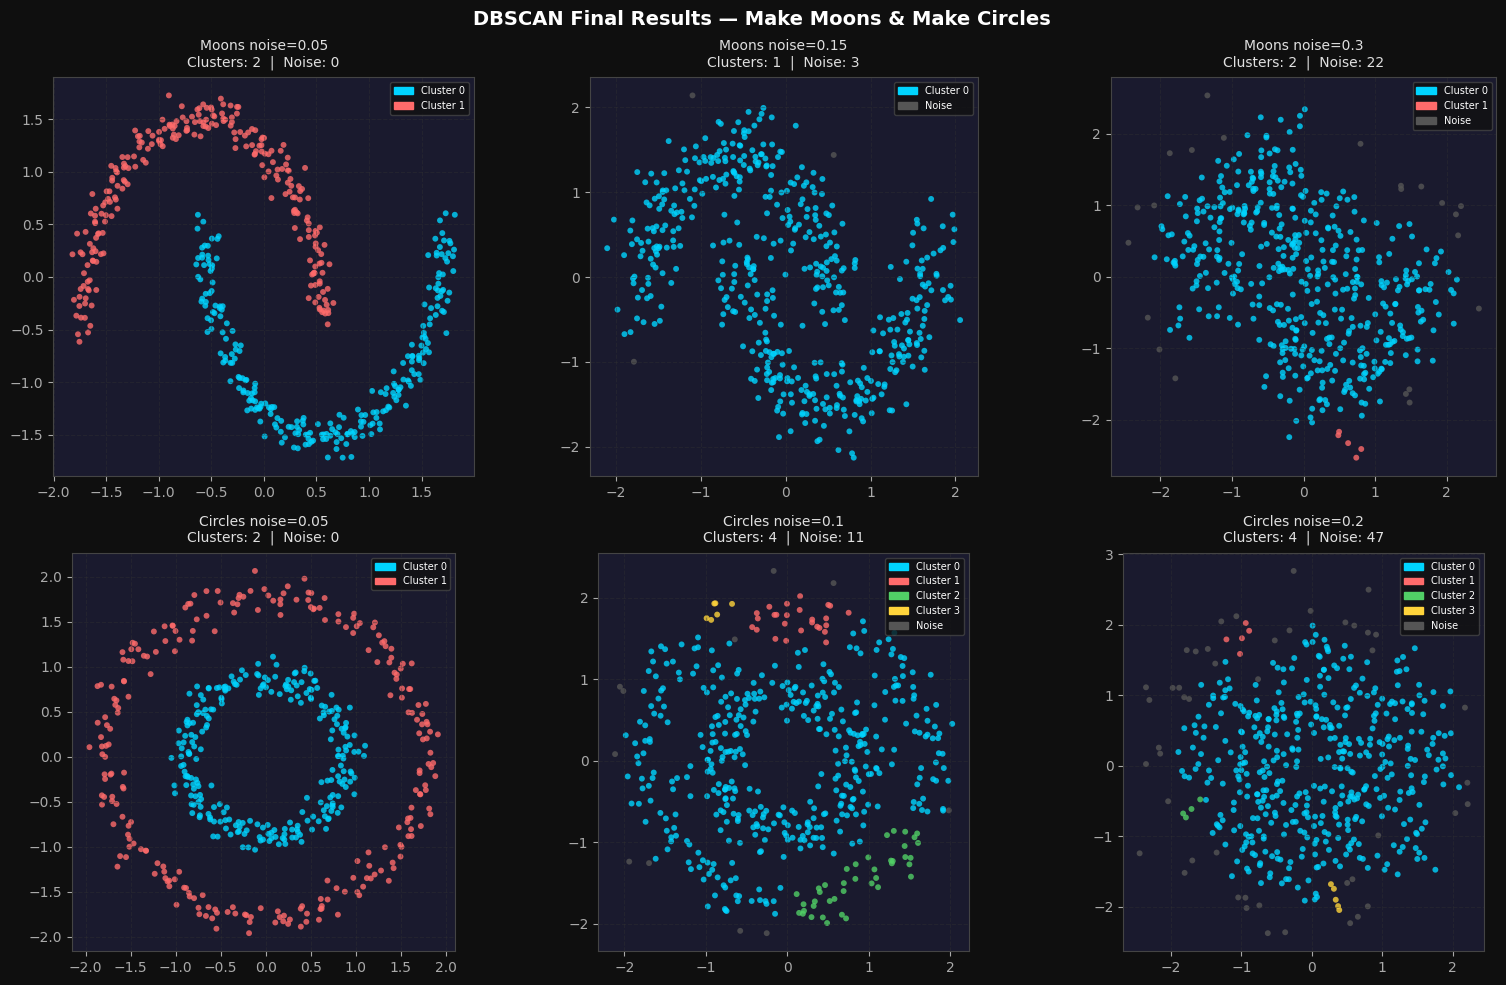

Summary plot saved ✓


In [15]:
# ── Best results side-by-side ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('DBSCAN Final Results — Make Moons & Make Circles',
             fontsize=14, fontweight='bold', color='white')

# Moons row
for ax, noise in zip(axes[0], noise_levels):
    X_n, _ = moons_datasets[noise]
    labels  = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_n)
    plot_clusters(ax, X_n, labels, f'Moons noise={noise}')

# Circles row
for ax, noise in zip(axes[1], noise_levels_c):
    X_n, _ = circles_by_noise[noise]
    labels  = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_n)
    plot_clusters(ax, X_n, labels, f'Circles noise={noise}')

plt.tight_layout()
plt.savefig('dbscan_final_summary.png', dpi=120, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Summary plot saved ✓")

---
## 7. Key Takeaways

| Dataset | Best DBSCAN Params | Silhouette | Why it works |
|---------|-------------------|------------|--------------|
| Make Moons (low noise) | ε=0.3, min_samples=5 | ~0.50–0.65 | Dense, well-separated arcs |
| Make Moons (high noise) | ε=0.3, min_samples=5 | Lower | More noise pollutes clusters |
| Make Circles (small factor) | ε=0.25, min_samples=5 | ~0.55–0.70 | Large density gap between rings |
| Make Circles (large factor) | ε=0.25, min_samples=5 | Lower | Rings overlap → harder to separate |

### DBSCAN Strengths
- ✅ Discovers **arbitrary-shaped** clusters (moons, rings, spirals)
- ✅ Automatically identifies and labels **noise/outliers**
- ✅ Does **not** require specifying the number of clusters

### DBSCAN Weaknesses
- ⚠️ Struggles with **varying density** clusters (different ε needed per region)
- ⚠️ Sensitive to `ε` — use the k-distance elbow plot to guide selection
- ⚠️ High-dimensional data degrades performance (curse of dimensionality)

### When to use DBSCAN
- Spatial data (GPS, geospatial clustering)
- Anomaly/outlier detection
- When clusters have irregular shapes
- When the number of clusters is unknown